# Daily Challenge : NumPy, Pandas et Matplotlib

**Objectif :** Analyser et visualiser des tendances de température mondiales en combinant NumPy, Pandas et Matplotlib.

**Scénario :** Je suis analyste de données et je travaille sur un jeu de données météo mondial. Mon objectif est d'analyser les tendances de température et de visualiser les résultats.

Ce notebook est divisé en 3 grandes parties :
1. Préparation des données
2. Analyse des données
3. Visualisation des données


## 1. Préparation des données

On commence par importer les bibliothèques dont on a besoin, puis on génère un tableau NumPy de température moyenne mensuelle (en °C) pour 10 villes sur 12 mois, avec des valeurs comprises entre -5°C et 35°C.

On fixe une "graine" (`seed`) aléatoire pour que les résultats soient toujours les mêmes à chaque exécution (utile pour comparer / reproduire les résultats).

In [1]:
# Importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# On fixe la graine aléatoire pour avoir des résultats reproductibles
np.random.seed(42)


### Génération des données avec NumPy

On utilise `np.random.uniform(low, high, size)` pour générer des nombres décimaux aléatoires entre -5 et 35.
- `low` = -5 (température minimale)
- `high` = 35 (température maximale)
- `size` = (10, 12) car on veut 10 lignes (villes) et 12 colonnes (mois)

In [2]:
# Génération d'un tableau NumPy : 10 villes x 12 mois, températures entre -5 et 35°C
temperatures = np.random.uniform(low=-5, high=35, size=(10, 12))

# Affichage des dimensions et d'un aperçu du tableau
print("Dimensions du tableau :", temperatures.shape)
print(temperatures)


Dimensions du tableau : (10, 12)
[[ 9.98160475 33.02857226 24.27975767 18.94633937  1.24074562  1.23978081
  -2.67665551 29.64704583 19.04460047 23.32290311 -4.17662023 33.79639409]
 [28.29770563  3.49356443  2.27299869  2.33618039  7.16968972 15.99025727
  12.27780075  6.64916561 19.47411579  0.57975443  6.68578594  9.65447373]
 [13.24279937 26.40703846  2.98695129 15.56937754 18.69658275 -3.14198349
  19.30179408  1.82096495 -2.39793628 32.95542149 33.62528132 27.33589392]
 [ 7.18455077 -1.09311544 22.36932106 12.60609975 -0.11847061 14.8070764
  -3.62445916 31.37281608  5.35119926 21.50089137  7.46844304 15.80272085]
 [16.86841117  2.39417822 33.78338511 26.00531293 32.57995766 30.79309402
  18.91599915 31.8749694  -1.46029992  2.8393145  -3.19090844  8.01321323]
 [10.54709159  5.85396127 28.14950037  9.27013307  6.23738039 16.70784333
   0.636969   27.08787923 -2.01797425 34.47547746 25.88979077  2.94862726]
 [-4.77911532 27.61845714 23.27429375 24.16028672 25.85081387 -2.03821393


### Conversion en DataFrame Pandas

On transforme le tableau NumPy en `DataFrame` Pandas pour pouvoir manipuler les données plus facilement :
- Les **lignes** (index) sont les noms des villes
- Les **colonnes** sont les noms des mois

In [3]:
# Liste des noms de villes (index du DataFrame)
villes = [f"City {i+1}" for i in range(10)]

# Liste des mois (colonnes du DataFrame)
mois = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Création du DataFrame
df_temperatures = pd.DataFrame(temperatures, index=villes, columns=mois)

# On arrondit à 2 décimales pour que ce soit plus lisible
df_temperatures = df_temperatures.round(2)

df_temperatures


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City 1,9.98,33.03,24.28,18.95,1.24,1.24,-2.68,29.65,19.04,23.32,-4.18,33.80
City 2,28.30,3.49,2.27,2.34,7.17,15.99,12.28,6.65,19.47,0.58,6.69,9.65
City 3,13.24,26.41,2.99,15.57,18.70,-3.14,19.30,1.82,-2.40,32.96,33.63,27.34
City 4,7.18,-1.09,22.37,12.61,-0.12,14.81,-3.62,31.37,5.35,21.50,7.47,15.80
City 5,16.87,2.39,33.78,26.01,32.58,30.79,18.92,31.87,-1.46,2.84,-3.19,8.01
City 6,10.55,5.85,28.15,9.27,6.24,16.71,0.64,27.09,-2.02,34.48,25.89,2.95
City 7,-4.78,27.62,23.27,24.16,25.85,-2.04,9.34,-0.37,29.52,19.93,8.24,-2.46
City 8,7.44,8.01,24.18,20.50,30.49,13.89,-0.22,23.53,25.43,17.45,25.84,14.75
City 9,15.91,12.10,-3.98,-0.68,-3.74,20.46,7.57,15.34,31.30,4.97,11.42,25.22
City 10,4.15,-1.92,6.59,1.45,32.19,27.32,20.34,29.86,27.15,2.46,30.70,16.57


## 2. Analyse des données

### Moyenne annuelle par ville

On calcule la moyenne des 12 mois pour chaque ville avec `DataFrame.mean(axis=1)`.
- `axis=1` veut dire qu'on fait la moyenne **le long des colonnes**, donc pour chaque ligne (chaque ville).

In [4]:
# Moyenne annuelle pour chaque ville
moyenne_annuelle = df_temperatures.mean(axis=1).round(2)

print("Température moyenne annuelle par ville :")
moyenne_annuelle


Température moyenne annuelle par ville :


City 1     15.64
City 2      9.57
City 3     15.53
City 4     11.14
City 5     16.62
City 6     13.82
City 7     13.19
City 8     17.61
City 9     11.32
City 10    16.40
dtype: float64

### Ville la plus chaude et la plus froide

On utilise :
- `idxmax()` pour trouver l'index (la ville) avec la valeur la plus haute
- `idxmin()` pour trouver l'index (la ville) avec la valeur la plus basse

In [5]:
# Ville avec la température moyenne la plus élevée
ville_plus_chaude = moyenne_annuelle.idxmax()
temp_plus_chaude = moyenne_annuelle.max()

# Ville avec la température moyenne la plus basse
ville_plus_froide = moyenne_annuelle.idxmin()
temp_plus_froide = moyenne_annuelle.min()

print(f"Ville la plus chaude : {ville_plus_chaude} ({temp_plus_chaude}°C de moyenne annuelle)")
print(f"Ville la plus froide : {ville_plus_froide} ({temp_plus_froide}°C de moyenne annuelle)")


Ville la plus chaude : City 8 (17.61°C de moyenne annuelle)
Ville la plus froide : City 2 (9.57°C de moyenne annuelle)


## 3. Visualisation des données

### Graphique 1 : Évolution mensuelle de la température pour chaque ville

Ce graphique en courbes (line plot) montre comment la température évolue mois par mois, pour chacune des 10 villes.

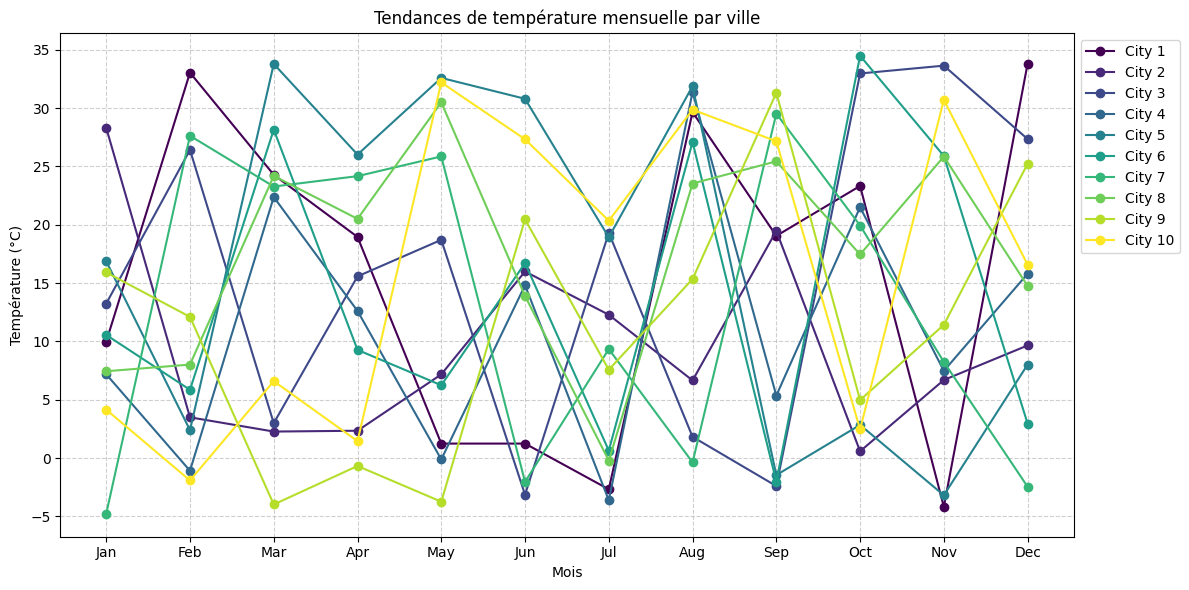

In [6]:
# On utilise une palette de couleurs (colormap) pour bien distinguer les 10 villes
couleurs = plt.cm.viridis(np.linspace(0, 1, len(villes)))

plt.figure(figsize=(12, 6))

for i, ville in enumerate(villes):
    plt.plot(mois, df_temperatures.loc[ville], marker='o', label=ville, color=couleurs[i])

plt.title("Tendances de température mensuelle par ville")
plt.xlabel("Mois")
plt.ylabel("Température (°C)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # légende à droite du graphique
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Graphique 2 : Moyenne annuelle par ville (diagramme en barres)

Ce graphique permet de comparer plus facilement la moyenne annuelle de chaque ville, et de repérer en un coup d'œil la ville la plus chaude et la plus froide.

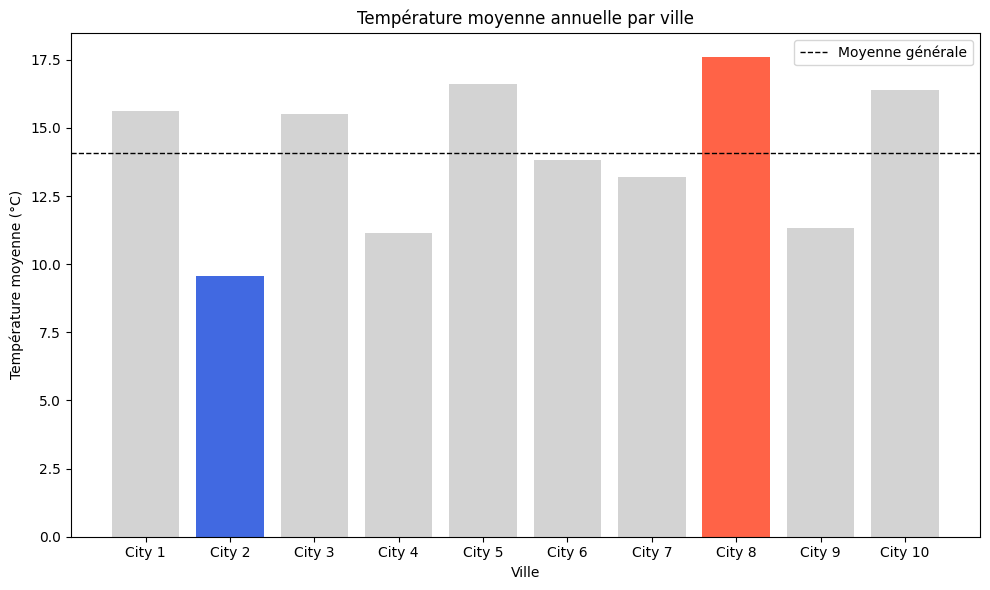

In [7]:
plt.figure(figsize=(10, 6))

# On colore en rouge la ville la plus chaude, en bleu la plus froide, en gris les autres
couleurs_barres = []
for ville in villes:
    if ville == ville_plus_chaude:
        couleurs_barres.append('tomato')
    elif ville == ville_plus_froide:
        couleurs_barres.append('royalblue')
    else:
        couleurs_barres.append('lightgrey')

plt.bar(moyenne_annuelle.index, moyenne_annuelle.values, color=couleurs_barres)

plt.title("Température moyenne annuelle par ville")
plt.xlabel("Ville")
plt.ylabel("Température moyenne (°C)")
plt.axhline(moyenne_annuelle.mean(), color='black', linestyle='--', linewidth=1, label="Moyenne générale")
plt.legend()
plt.tight_layout()
plt.show()


### Graphique 3 : Carte de chaleur (heatmap) des températures

Une heatmap permet de visualiser toutes les données en un seul coup d'œil : plus la couleur est chaude (jaune/rouge), plus la température est élevée ; plus elle est froide (violet/bleu), plus la température est basse.

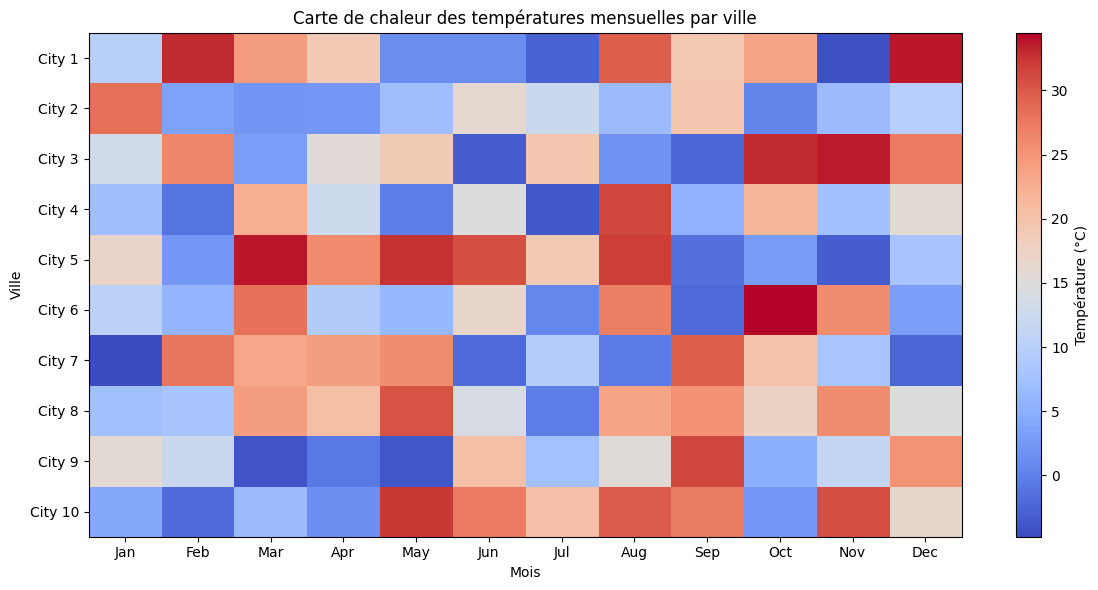

In [8]:
plt.figure(figsize=(12, 6))

plt.imshow(df_temperatures, cmap='coolwarm', aspect='auto')
plt.colorbar(label="Température (°C)")

plt.xticks(ticks=np.arange(len(mois)), labels=mois)
plt.yticks(ticks=np.arange(len(villes)), labels=villes)

plt.title("Carte de chaleur des températures mensuelles par ville")
plt.xlabel("Mois")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()


## 📝 Rapport de synthèse

In [9]:
ecart = (moyenne_annuelle.max() - moyenne_annuelle.min())

print("Résumé de l'analyse")
print("--------------------")
print(f"- Ville la plus chaude en moyenne sur l'année : {ville_plus_chaude} ({temp_plus_chaude}°C)")
print(f"- Ville la plus froide en moyenne sur l'année : {ville_plus_froide} ({temp_plus_froide}°C)")
print(f"- Écart entre la ville la plus chaude et la plus froide : {round(ecart, 2)}°C")
print(f"- Température moyenne générale (toutes villes confondues) : {round(moyenne_annuelle.mean(), 2)}°C")


Résumé de l'analyse
--------------------
- Ville la plus chaude en moyenne sur l'année : City 8 (17.61°C)
- Ville la plus froide en moyenne sur l'année : City 2 (9.57°C)
- Écart entre la ville la plus chaude et la plus froide : 8.04°C
- Température moyenne générale (toutes villes confondues) : 14.08°C


### Observations

- Les données étant générées de manière aléatoire (avec `np.random.uniform`), les températures ne suivent pas un cycle saisonnier réaliste (pas de "vrai" été ou hiver) : les courbes du premier graphique sont assez irrégulières, avec des montées et descentes brusques d'un mois à l'autre.
- Malgré ce caractère aléatoire, en calculant la **moyenne annuelle** par ville, on arrive à dégager une tendance claire et à identifier la ville la plus chaude et la ville la plus froide (voir le diagramme en barres ci-dessus).
- La carte de chaleur (heatmap) permet de repérer rapidement les valeurs extrêmes (cases très rouges = pics de chaleur, cases très bleues = pics de froid) sans avoir à lire chaque chiffre du tableau.
- Dans un cas réel (vraies données météo), on s'attendrait à voir des courbes plus régulières, avec des températures qui montent en été et qui descendent en hiver, ce qui n'est pas le cas ici puisque les données sont purement aléatoires.

### Conclusion

Ce projet montre comment **NumPy** (génération de données numériques), **Pandas** (organisation et analyse des données sous forme de tableau) et **Matplotlib** (visualisation) se complètent pour transformer des données brutes en informations claires et exploitables.